# Adversarial Natural Language Inference (ANLI) — Round 2
## Exploratory Data Analysis

**Objective:** Build a 3-way NLI classifier (entailment, neutral, contradiction) on the ANLI Round 2 dataset. This notebook performs comprehensive EDA to understand the data characteristics, identify challenges, and inform modeling decisions.

**Why ANLI is Hard:** Unlike SNLI/MNLI, ANLI was collected via an adversarial human-and-model-in-the-loop process (HAMLET). Annotators wrote hypotheses specifically designed to fool a RoBERTa model, meaning surface-level heuristics (lexical overlap, negation words) are unreliable predictors. Round 2 used an ensemble of RoBERTa models trained on SNLI + MNLI + FEVER-NLI + R1 data as the adversary.

**Paper:** Nie et al. (2020) — *Adversarial NLI: A New Benchmark for Natural Language Understanding*

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [4]:
# Dependencies
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from datasets import load_dataset

In [3]:
!pip install datasets

  Using cached pyarrow-23.0.1-cp313-cp313-win_amd64.whl.metadata (3.1 kB)
  Using cached dill-0.4.1-py3-none-any.whl.metadata (10 kB)
  Using cached xxhash-3.6.0-cp313-cp313-win_amd64.whl.metadata (13 kB)
  Using cached multiprocess-0.70.19-py313-none-any.whl.metadata (7.5 kB)
  Using cached aiohttp-3.13.3-cp313-cp313-win_amd64.whl.metadata (8.4 kB)
  Using cached aiohappyeyeballs-2.6.1-py3-none-any.whl.metadata (5.9 kB)
  Using cached aiosignal-1.4.0-py3-none-any.whl.metadata (3.7 kB)
  Using cached frozenlist-1.8.0-cp313-cp313-win_amd64.whl.metadata (21 kB)
  Using cached multidict-6.7.1-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached propcache-0.4.1-cp313-cp313-win_amd64.whl.metadata (14 kB)
  Using cached yarl-1.23.0-cp313-cp313-win_amd64.whl.metadata (82 kB)
   ---------------------------------------- 0.0/527.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/527.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/527.0 kB ? eta -:--:--
  


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
# Consistent styling
plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
})
PALETTE = {"entailment": "#1D9E75", "neutral": "#534AB7", "contradiction": "#D85A30"}

## Dataset

In [6]:
# Load all splits for all rounds
dataset = load_dataset("facebook/anli")

In [7]:
train = dataset["train_r2"].to_pandas()
dev   = dataset["dev_r2"].to_pandas()
test  = dataset["test_r2"].to_pandas()

In [8]:
# Map integer labels to readable strings
LABEL_MAP = {0: "entailment", 1: "neutral", 2: "contradiction"}
for df in [train, dev, test]:
    df["label_name"] = df["label"].map(LABEL_MAP)

In [9]:
# Understanding the size of the splits
print(f"Train size: {len(train):,}")
print(f"Dev size:   {len(dev):,}")
print(f"Test size:  {len(test):,}")

Train size: 45,460
Dev size:   1,000
Test size:  1,000


## Data Schema and Sample Inspection
Each example contains:
- **`uid`** — unique identifier
- **`premise`** — a factual passage (sourced from Wikipedia via HotpotQA)
- **`hypothesis`** — a statement written by a human annotator to fool the model
- **`label`** — 0 (entailment), 1 (neutral), 2 (contradiction)
- **`reason`** — optional annotator explanation (often empty in R2)

In [10]:
print("=== Column dtypes ===")
print(train.dtypes)
print(f"\n=== Null counts (train) ===")
print(train.isnull().sum())
print(f"\n=== Unique UIDs (train): {train['uid'].nunique()} / {len(train)} rows ===")

=== Column dtypes ===
uid           object
premise       object
hypothesis    object
label          int64
reason        object
label_name    object
dtype: object

=== Null counts (train) ===
uid           0
premise       0
hypothesis    0
label         0
reason        0
label_name    0
dtype: int64

=== Unique UIDs (train): 45460 / 45460 rows ===


In [11]:
# Show a few examples per class for intuition
for label_name in ["entailment", "neutral", "contradiction"]:
    print(f"\n{'='*80}")
    print(f"  CLASS: {label_name.upper()}")
    print(f"{'='*80}")
    sample = train[train["label_name"] == label_name].sample(2, random_state=42)
    for _, row in sample.iterrows():
        print(f"\nPremise:    {row['premise'][:200]}...")
        print(f"Hypothesis: {row['hypothesis']}")
        print(f"Reason:     {row['reason'] if row['reason'] else '(none)'}")


  CLASS: ENTAILMENT

Premise:    Rewire (formerly RH Reality Check, long name Reproductive Health Reality Check) is a website focused on reproductive and sexual health from a pro-reproductive rights perspective. The website began as ...
Hypothesis: Rewire is not a for profit organization. 
Reason:     (none)

Premise:    Drifters is a British sitcom that stars Jessica Knappett, Lydia Rose Bewley and Lauren O'Rourke as three female friends who live in Leeds following their graduation from university. All three actresse...
Hypothesis: Jessica Knappett, Lydia Rose Bewley and Lauren O'Rourke appeared together in more than one film.
Reason:     (none)

  CLASS: NEUTRAL

Premise:    The Granada Theater is a theatre located in Lower Greenville, in Dallas, TX. The theatre was built in 1946 as a movie house. In 1977, it was converted to a concert hall, only to revert to a movie thea...
Hypothesis: granada theater has more than 100 seats.
Reason:     (none)

Premise:    Florence MacLeod Harper 

## Label Distribution

**Key Question:** Is the dataset balanced? Imbalanced classes would require stratified sampling, class weights, or oversampling during training.

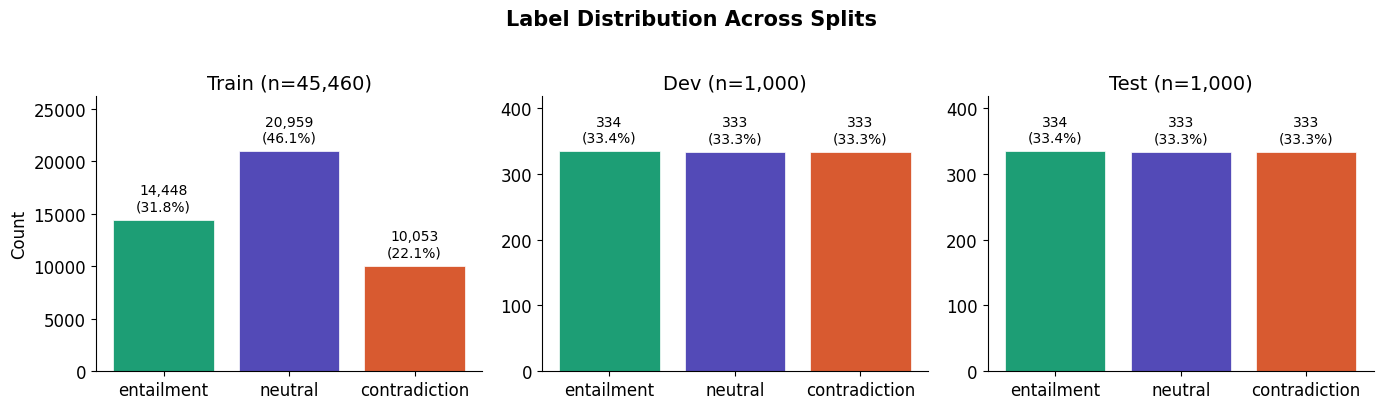

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (name, df) in zip(axes, [("Train", train), ("Dev", dev), ("Test", test)]):
    counts = df["label_name"].value_counts().reindex(["entailment", "neutral", "contradiction"])
    bars = ax.bar(counts.index, counts.values,
                  color=[PALETTE[l] for l in counts.index], edgecolor="white", linewidth=0.5)
    ax.set_title(f"{name} (n={len(df):,})")
    ax.set_ylabel("Count" if ax == axes[0] else "")
    offset = counts.max() * 0.03
    for bar, val in zip(bars, counts.values):
        pct = val / len(df) * 100
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + offset,
                f"{val:,}\n({pct:.1f}%)", ha="center", va="bottom", fontsize=10)
    ax.set_ylim(0, counts.max() * 1.25)

fig.suptitle("Label Distribution Across Splits", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("figures/label_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## Text Length Analysis

Understanding length distributions is critical for choosing `max_length` during tokenization. Too short → truncation loses context. Too long → wasted compute and memory.

In [13]:
for df, name in [(train, "train"), (dev, "dev"), (test, "test")]:
    df[f"premise_words"]    = df["premise"].apply(lambda x: len(x.split()))
    df[f"hypothesis_words"] = df["hypothesis"].apply(lambda x: len(x.split()))
    df[f"premise_chars"]    = df["premise"].str.len()
    df[f"hypothesis_chars"] = df["hypothesis"].str.len()
    df["total_words"]       = df["premise_words"] + df["hypothesis_words"]

In [14]:
# Summary statistics
length_stats = train[["premise_words", "hypothesis_words", "total_words"]].describe().round(1)
print("=== Train Set: Word Length Statistics ===")
print(length_stats)

=== Train Set: Word Length Statistics ===
       premise_words  hypothesis_words  total_words
count        45460.0           45460.0      45460.0
mean            54.0              10.0         63.9
std              8.2               5.3          9.9
min             33.0               3.0         37.0
25%             47.0               7.0         57.0
50%             54.0               9.0         64.0
75%             60.0              11.0         70.0
max             76.0              65.0        136.0


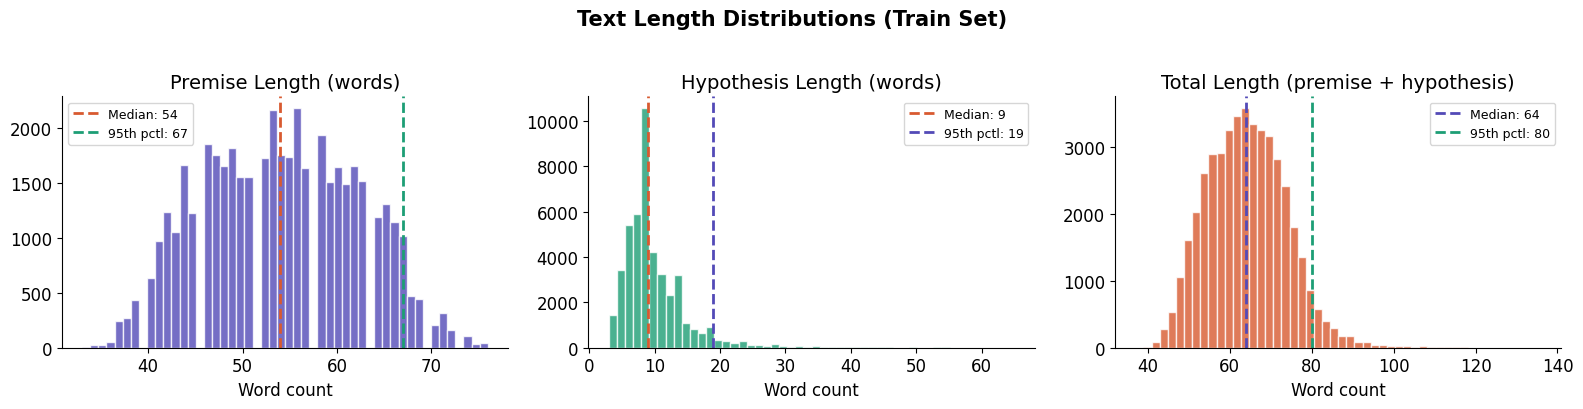

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Premise length distribution
axes[0].hist(train["premise_words"], bins=50, color="#534AB7", alpha=0.8, edgecolor="white")
axes[0].axvline(train["premise_words"].median(), color="#D85A30", ls="--", lw=2,
                label=f"Median: {train['premise_words'].median():.0f}")
axes[0].axvline(train["premise_words"].quantile(0.95), color="#1D9E75", ls="--", lw=2,
                label=f"95th pctl: {train['premise_words'].quantile(0.95):.0f}")
axes[0].set_title("Premise Length (words)")
axes[0].set_xlabel("Word count")
axes[0].legend(fontsize=9)

# Hypothesis length distribution
axes[1].hist(train["hypothesis_words"], bins=50, color="#1D9E75", alpha=0.8, edgecolor="white")
axes[1].axvline(train["hypothesis_words"].median(), color="#D85A30", ls="--", lw=2,
                label=f"Median: {train['hypothesis_words'].median():.0f}")
axes[1].axvline(train["hypothesis_words"].quantile(0.95), color="#534AB7", ls="--", lw=2,
                label=f"95th pctl: {train['hypothesis_words'].quantile(0.95):.0f}")
axes[1].set_title("Hypothesis Length (words)")
axes[1].set_xlabel("Word count")
axes[1].legend(fontsize=9)

# Total (premise + hypothesis) — critical for max_length
axes[2].hist(train["total_words"], bins=50, color="#D85A30", alpha=0.8, edgecolor="white")
axes[2].axvline(train["total_words"].median(), color="#534AB7", ls="--", lw=2,
                label=f"Median: {train['total_words'].median():.0f}")
axes[2].axvline(train["total_words"].quantile(0.95), color="#1D9E75", ls="--", lw=2,
                label=f"95th pctl: {train['total_words'].quantile(0.95):.0f}")
axes[2].set_title("Total Length (premise + hypothesis)")
axes[2].set_xlabel("Word count")
axes[2].legend(fontsize=9)

fig.suptitle("Text Length Distributions (Train Set)", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("figures/text_lengths.png", dpi=150, bbox_inches="tight")
plt.show()

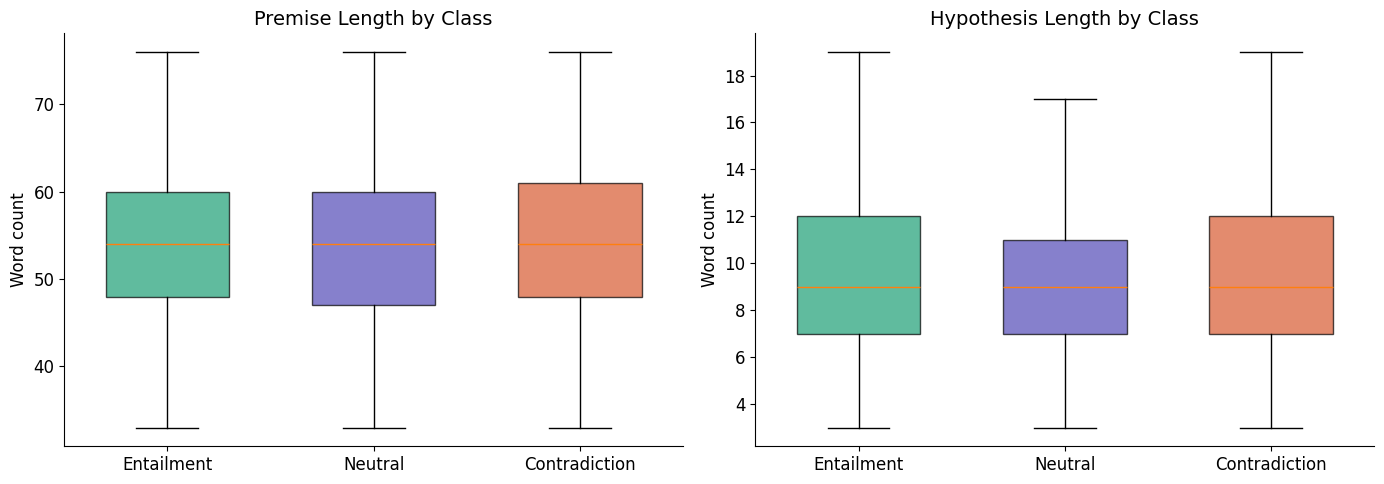

In [17]:
# Length by class — do certain classes have longer/shorter hypotheses?
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, title in zip(axes,
                           ["premise_words", "hypothesis_words"],
                           ["Premise Length by Class", "Hypothesis Length by Class"]):
    data = [train[train["label_name"] == l][col] for l in ["entailment", "neutral", "contradiction"]]
    bp = ax.boxplot(data, labels=["Entailment", "Neutral", "Contradiction"],
                    patch_artist=True, widths=0.6, showfliers=False)
    for patch, color in zip(bp["boxes"], [PALETTE["entailment"], PALETTE["neutral"], PALETTE["contradiction"]]):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_title(title)
    ax.set_ylabel("Word count")

plt.tight_layout()
plt.savefig("figures/length_by_class.png", dpi=150, bbox_inches="tight")
plt.show()

## Tokenization Analysis (DeBERTa-v3)

Since we plan to use DeBERTa-v3 as our primary model, let's check how many subword tokens the premise+hypothesis pairs produce and what `max_length` we need.

In [18]:
from transformers import DebertaV2Tokenizer
import os

# Note: AutoTokenizer.from_pretrained() can fail due to spm.model parsing issues.
# Loading DebertaV2Tokenizer with an explicit vocab_file path resolves this.
# The spm.model file must be downloaded first (see deberta_tokenizer/ directory).
tokenizer = DebertaV2Tokenizer(
    vocab_file=os.path.join("deberta_tokenizer", "spm.model"),
    do_lower_case=False,
)

token_lengths = [
    len(tokenizer(p, h, truncation=False)["input_ids"])
    for p, h in zip(train["premise"].tolist(), train["hypothesis"].tolist())
]
train["token_length"] = token_lengths

print(f"=== DeBERTa-v3 Token Length Statistics (all {len(train):,} examples) ===")
print(pd.Series(token_lengths).describe().round(1))
print(f"\n% fitting in 256 tokens: {(pd.Series(token_lengths) <= 256).mean()*100:.1f}%")
print(f"% fitting in 384 tokens: {(pd.Series(token_lengths) <= 384).mean()*100:.1f}%")
print(f"% fitting in 512 tokens: {(pd.Series(token_lengths) <= 512).mean()*100:.1f}%")


ImportError: 
DebertaV2Tokenizer requires the SentencePiece library but it was not found in your environment. Check out the instructions on the
installation page of its repo: https://github.com/google/sentencepiece#installation and follow the ones
that match your environment. Please note that you may need to restart your runtime after installation.


In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(token_lengths, bins=60, color="#534AB7", alpha=0.8, edgecolor="white")
for cutoff, color, label in [(256, "#D85A30", "256"), (384, "#1D9E75", "384"), (512, "#888780", "512")]:
    ax.axvline(cutoff, color=color, ls="--", lw=2, label=f"max_length={label}")
ax.set_title("DeBERTa-v3 Token Length Distribution (Premise + Hypothesis)")
ax.set_xlabel("Number of subword tokens")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.savefig("figures/token_lengths.png", dpi=150, bbox_inches="tight")
plt.show()

## Lexical Overlap Analysis

**Why this matters:** In non-adversarial NLI datasets (SNLI, MNLI), high word overlap between premise and hypothesis is a strong signal for entailment, and low overlap correlates with contradiction. ANLI was designed to break this heuristic.

In [19]:
def jaccard_similarity(text1, text2):
    """Compute word-level Jaccard similarity between two texts."""
    words1 = set(text1.lower().split())
    words2 = set(text2.lower().split())
    if not words1 or not words2:
        return 0.0
    return len(words1 & words2) / len(words1 | words2)

In [20]:
def word_overlap_ratio(premise, hypothesis):
    """Fraction of hypothesis words that appear in the premise."""
    p_words = set(premise.lower().split())
    h_words = set(hypothesis.lower().split())
    if not h_words:
        return 0.0
    return len(h_words & p_words) / len(h_words)

In [21]:
train["jaccard"]  = train.apply(lambda r: jaccard_similarity(r["premise"], r["hypothesis"]), axis=1)
train["h_overlap"] = train.apply(lambda r: word_overlap_ratio(r["premise"], r["hypothesis"]), axis=1)

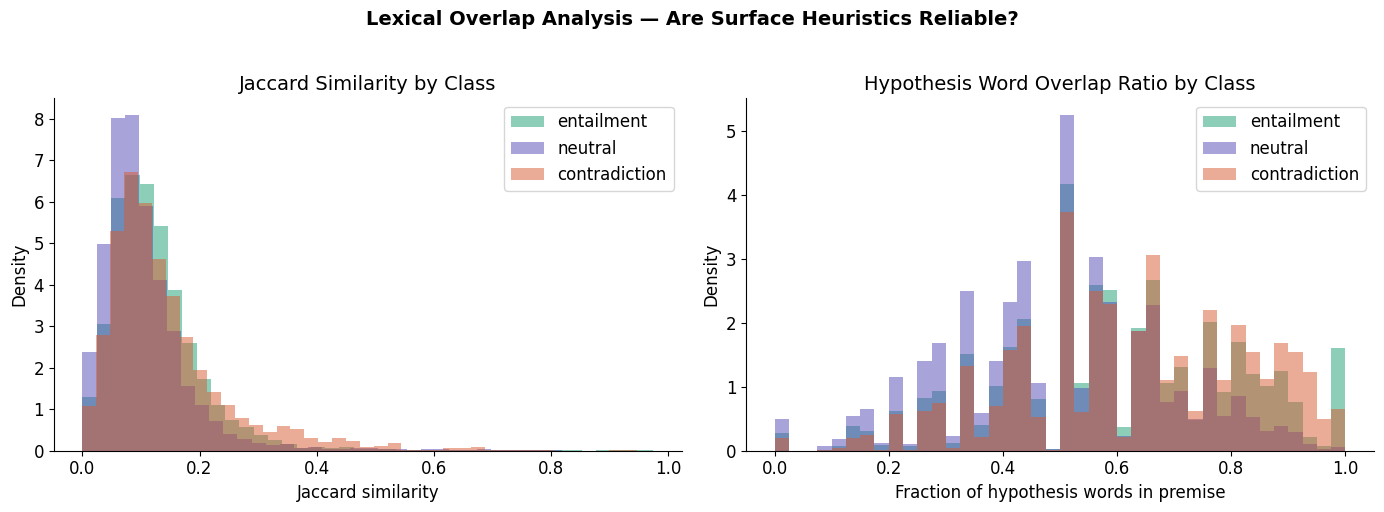

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Jaccard similarity by class
for label in ["entailment", "neutral", "contradiction"]:
    subset = train[train["label_name"] == label]
    axes[0].hist(subset["jaccard"], bins=40, alpha=0.5, label=label, color=PALETTE[label], density=True)
axes[0].set_title("Jaccard Similarity by Class")
axes[0].set_xlabel("Jaccard similarity")
axes[0].set_ylabel("Density")
axes[0].legend()

# Hypothesis word overlap by class
for label in ["entailment", "neutral", "contradiction"]:
    subset = train[train["label_name"] == label]
    axes[1].hist(subset["h_overlap"], bins=40, alpha=0.5, label=label, color=PALETTE[label], density=True)
axes[1].set_title("Hypothesis Word Overlap Ratio by Class")
axes[1].set_xlabel("Fraction of hypothesis words in premise")
axes[1].set_ylabel("Density")
axes[1].legend()

fig.suptitle("Lexical Overlap Analysis — Are Surface Heuristics Reliable?",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("figures/lexical_overlap.png", dpi=150, bbox_inches="tight")
plt.show()

In [23]:
# Summary statistics per class
overlap_summary = train.groupby("label_name")[["jaccard", "h_overlap"]].agg(["mean", "median", "std"]).round(4)
print("=== Lexical Overlap Summary by Class ===")
print(overlap_summary)
print("\n→ If the distributions heavily overlap across classes, it confirms that")
print("  lexical overlap is NOT a reliable feature — as expected in adversarial NLI.")


=== Lexical Overlap Summary by Class ===
              jaccard                 h_overlap                
                 mean  median     std      mean  median     std
label_name                                                     
contradiction  0.1449  0.1154  0.1084    0.6302  0.6364  0.2044
entailment     0.1262  0.1087  0.0869    0.5930  0.6000  0.2081
neutral        0.1050  0.0877  0.0785    0.4977  0.5000  0.1883

→ If the distributions heavily overlap across classes, it confirms that
  lexical overlap is NOT a reliable feature — as expected in adversarial NLI.


## Linguistic Phenomena Analysis
The original ANLI paper identified several reasoning types that annotators used: numerical reasoning, negation, quantifiers, world knowledge, taxonomic knowledge, and coreference. Let's detect and quantify these patterns in hypotheses.

In [24]:
# Define pattern detectors
NEGATION_WORDS = {"not", "no", "never", "neither", "nobody", "nothing", "nowhere",
                  "nor", "cannot", "can't", "won't", "don't", "doesn't", "didn't",
                  "isn't", "aren't", "wasn't", "weren't", "hasn't", "haven't",
                  "hadn't", "wouldn't", "shouldn't", "couldn't", "mustn't"}

QUANTIFIER_WORDS = {"all", "every", "each", "any", "some", "most", "many", "few",
                    "several", "none", "both", "only", "more", "less", "at least",
                    "at most", "exactly", "approximately", "about", "over", "under"}

TEMPORAL_WORDS = {"before", "after", "during", "while", "when", "since", "until",
                  "first", "last", "earlier", "later", "recently", "always",
                  "sometimes", "often", "never", "already", "yet", "still"}

In [25]:
def has_negation(text):
    words = set(text.lower().split())
    return bool(words & NEGATION_WORDS) or "n't" in text.lower()

def has_numerical(text):
    return bool(re.search(r'\b\d+\b', text))

def has_quantifier(text):
    words = set(text.lower().split())
    return bool(words & QUANTIFIER_WORDS)

def has_temporal(text):
    words = set(text.lower().split())
    return bool(words & TEMPORAL_WORDS)

def has_comparison(text):
    return bool(re.search(r'\b(more|less|fewer|greater|better|worse|higher|lower|larger|smaller|longer|shorter)\b',
                          text, re.IGNORECASE))

In [26]:
# Apply detectors to hypotheses
train["has_negation"]   = train["hypothesis"].apply(has_negation)
train["has_numerical"]  = train["hypothesis"].apply(has_numerical)
train["has_quantifier"] = train["hypothesis"].apply(has_quantifier)
train["has_temporal"]   = train["hypothesis"].apply(has_temporal)
train["has_comparison"] = train["hypothesis"].apply(has_comparison)

In [27]:
# Aggregate: what fraction of each class uses each linguistic phenomenon?
phenomena = ["has_negation", "has_numerical", "has_quantifier", "has_temporal", "has_comparison"]
phenomena_labels = ["Negation", "Numerical", "Quantifier", "Temporal", "Comparison"]

rates = pd.DataFrame()
for label in ["entailment", "neutral", "contradiction"]:
    subset = train[train["label_name"] == label]
    rates[label] = [subset[p].mean() * 100 for p in phenomena]
rates.index = phenomena_labels

print("=== Linguistic Phenomena Rates (% of hypotheses per class) ===")
print(rates.round(1))

=== Linguistic Phenomena Rates (% of hypotheses per class) ===
            entailment  neutral  contradiction
Negation           7.9      6.5           14.2
Numerical         28.8     18.5           33.3
Quantifier        13.9     17.4           11.9
Temporal          13.0     12.5           14.0
Comparison         6.4      4.6            4.0


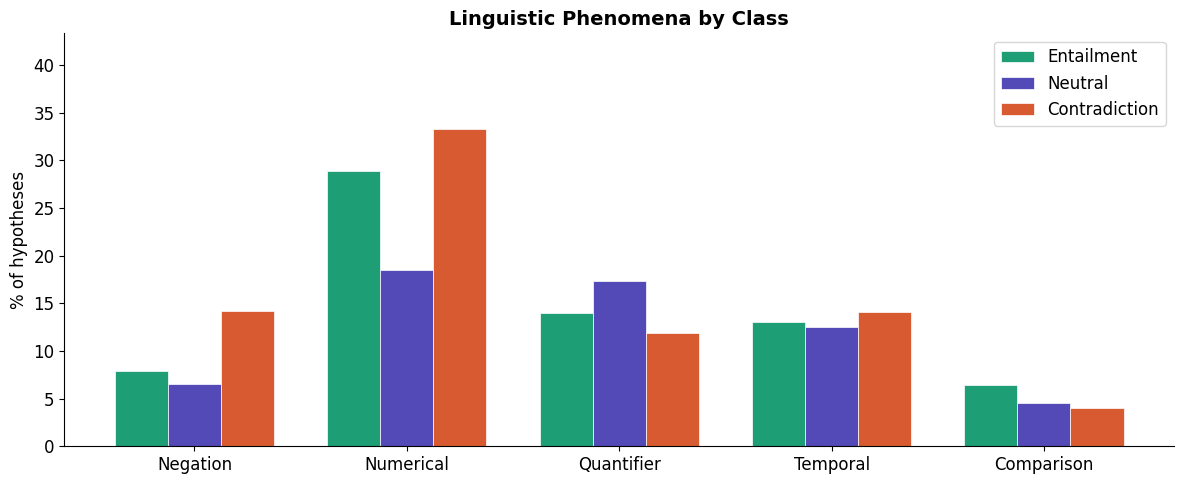

In [28]:
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(phenomena_labels))
width = 0.25

for i, label in enumerate(["entailment", "neutral", "contradiction"]):
    bars = ax.bar(x + i * width, rates[label], width, label=label.capitalize(),
                  color=PALETTE[label], edgecolor="white", linewidth=0.5)

ax.set_xticks(x + width)
ax.set_xticklabels(phenomena_labels)
ax.set_ylabel("% of hypotheses")
ax.set_title("Linguistic Phenomena by Class", fontsize=14, fontweight="bold")
ax.legend()
ax.set_ylim(0, rates.max().max() * 1.3)
plt.tight_layout()
plt.savefig("figures/linguistic_phenomena.png", dpi=150, bbox_inches="tight")
plt.show()

## Hypothesis-Only Bias Test

A well-known issue in NLI datasets: if a model can predict the label from the hypothesis alone (ignoring the premise), the dataset has annotation artifacts. ANLI was designed to minimize this. Let's verify by checking if hypothesis-only features correlate with labels.

In [ ]:
# Simple test: can hypothesis length alone predict the label?
fig, ax = plt.subplots(figsize=(10, 5))

data_by_class = [train[train["label_name"] == l]["hypothesis_words"] for l in ["entailment", "neutral", "contradiction"]]
bp = ax.boxplot(data_by_class, labels=["Entailment", "Neutral", "Contradiction"],
                patch_artist=True, showfliers=False, widths=0.5)
for patch, color in zip(bp["boxes"], [PALETTE["entailment"], PALETTE["neutral"], PALETTE["contradiction"]]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_title("Hypothesis Length by Class — Checking for Annotation Artifacts", fontsize=13, fontweight="bold")
ax.set_ylabel("Hypothesis word count")
plt.tight_layout()
plt.savefig("figures/hypothesis_only_bias.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# ANOVA test: are hypothesis lengths significantly different across classes?
from scipy.stats import f_oneway

groups = [train[train["label_name"] == l]["hypothesis_words"] for l in ["entailment", "neutral", "contradiction"]]
f_stat, p_val = f_oneway(*groups)
print(f"ANOVA test — Hypothesis length across classes:")
print(f"  F-statistic = {f_stat:.4f}, p-value = {p_val:.4f}")
print(f"  → {'Significant' if p_val < 0.05 else 'Not significant'} difference (α=0.05)")
print(f"  Mean lengths: E={groups[0].mean():.1f}, N={groups[1].mean():.1f}, C={groups[2].mean():.1f}")


## N-gram and Vocabulary Analysis

What words and phrases are most common in each class? Are there class-specific vocabulary patterns that a model might exploit?

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

def get_top_ngrams(texts, n=2, top_k=15):
    """Extract top-k most frequent n-grams from a collection of texts."""
    vec = CountVectorizer(ngram_range=(n, n), stop_words="english", max_features=10000)
    X = vec.fit_transform(texts)
    freqs = zip(vec.get_feature_names_out(), X.sum(axis=0).A1)
    return sorted(freqs, key=lambda x: x[1], reverse=True)[:top_k]

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, label in zip(axes, ["entailment", "neutral", "contradiction"]):
    subset = train[train["label_name"] == label]
    bigrams = get_top_ngrams(subset["hypothesis"], n=2, top_k=15)
    words, counts = zip(*bigrams)
    y_pos = np.arange(len(words))
    ax.barh(y_pos, counts, color=PALETTE[label], edgecolor="white", linewidth=0.5)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(words, fontsize=10)
    ax.invert_yaxis()
    ax.set_title(f"{label.capitalize()}", fontsize=13, fontweight="bold")
    ax.set_xlabel("Frequency")

fig.suptitle("Top 15 Hypothesis Bigrams by Class", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("figures/top_bigrams.png", dpi=150, bbox_inches="tight")
plt.show()

## Premise Source & Duplicate Analysis

Since premises come from Wikipedia via HotpotQA, multiple hypotheses may share the same premise. Let's check how this affects our data.

In [ ]:
# How many unique premises are there?
n_unique_premises = train["premise"].nunique()
n_total = len(train)
print(f"Unique premises: {n_unique_premises:,} / {n_total:,} total examples")
print(f"Average hypotheses per premise: {n_total / n_unique_premises:.2f}")

In [ ]:
# Distribution of hypotheses per premise
hyp_per_premise = train.groupby("premise").size()
print(f"\nHypotheses per premise:")
print(hyp_per_premise.describe().round(2))

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
hyp_per_premise.value_counts().sort_index().plot(kind="bar", color="#534AB7", edgecolor="white", ax=ax)
ax.set_title("Number of Hypotheses per Unique Premise", fontsize=13, fontweight="bold")
ax.set_xlabel("Hypotheses per premise")
ax.set_ylabel("Number of premises")
plt.tight_layout()
plt.savefig("figures/hypotheses_per_premise.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# Check for premise overlap between splits (potential data leakage)
train_premises = set(train["premise"].values)
dev_premises   = set(dev["premise"].values)
test_premises  = set(test["premise"].values)

print(f"Premise overlap — Train ∩ Dev:  {len(train_premises & dev_premises)}")
print(f"Premise overlap — Train ∩ Test: {len(train_premises & test_premises)}")
print(f"Premise overlap — Dev ∩ Test:   {len(dev_premises & test_premises)}")

## Reason Field Analysis

Some examples include annotator-provided reasons. While we won't use these as features, they give insight into annotator thinking and reasoning complexity.

In [ ]:
train["has_reason"] = train["reason"].apply(lambda x: bool(x) and len(str(x).strip()) > 0)
reason_rate = train.groupby("label_name")["has_reason"].mean() * 100

print("=== Annotator Reason Availability ===")
print(f"Overall: {train['has_reason'].mean()*100:.1f}% of examples have reasons")
print(f"\nBy class:")
for label in ["entailment", "neutral", "contradiction"]:
    print(f"  {label}: {reason_rate[label]:.1f}%")

# Show a few example reasons
if train["has_reason"].any():
    print("\n=== Sample Annotator Reasons ===")
    for _, row in train[train["has_reason"]].sample(min(5, train["has_reason"].sum()), random_state=42).iterrows():
        print(f"\n[{row['label_name'].upper()}]")
        print(f"  Hypothesis: {row['hypothesis']}")
        print(f"  Reason:     {row['reason']}")

## Correlation Heatmap — Feature Interactions

Let's see how our engineered features (lengths, overlap, linguistic patterns) relate to each other and to the target label.

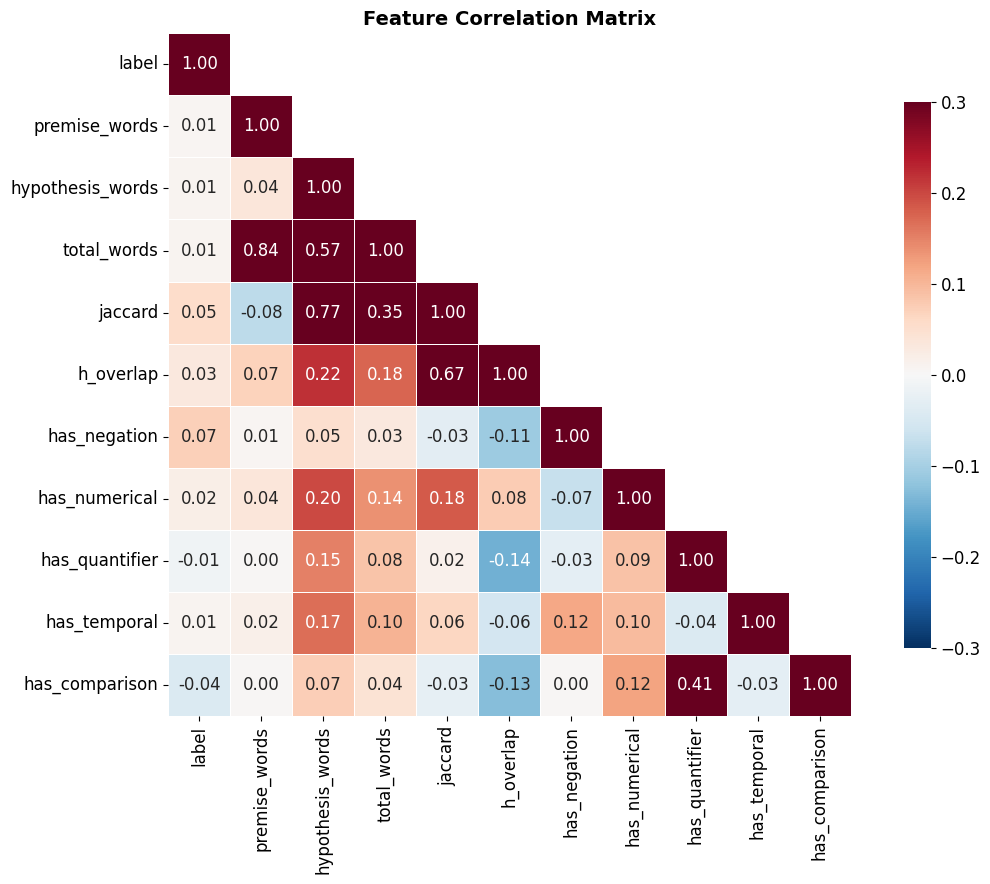

In [30]:
feature_cols = ["label", "premise_words", "hypothesis_words", "total_words",
                "jaccard", "h_overlap", "has_negation", "has_numerical",
                "has_quantifier", "has_temporal", "has_comparison"]

corr_matrix = train[feature_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-0.3, vmax=0.3, square=True, linewidths=0.5, ax=ax,
            cbar_kws={"shrink": 0.8})
ax.set_title("Feature Correlation Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## Summary of Key Findings

| Finding | Implication |
|---------|------------|
| **Class imbalance in train** (neutral 46%, contradiction 22%) | Consider class weights or stratified sampling |
| **Short sequences** (max 136 tokens, 100% fit in 256) | Use `max_length=128` or `160` with dynamic padding |
| **Lexical overlap NOT class-discriminative** | TF-IDF baselines will fail; need semantic understanding |
| **~17 hypotheses per premise** (867 shared premises with dev) | Not data leakage (different hypotheses), but worth noting |
| **Only 10.7% have annotator reasons** | Can't rely on reason field for analysis |
| **Hypothesis length practically identical across classes** | No annotation artifact via length |